# Project 2 — Startup Funding Prediction Model
## Predicting Funding Amounts and Stage Progression in the Indian Startup Ecosystem

**Core Research Question**: 
Can observable characteristics of an Indian startup — combined with network centrality features transferred from Project 1 — predict its subsequent funding amount or funding-stage outcome?

---

### Project Architecture & Bridge Linkage
Rather than treating venture evaluation in isolation, this study bridges **Project 1 (Empirical Founder–Investor Network Analysis)** and **Project 2 (Supervised Machine Learning & Predictive Modeling)**:
1. **Network Centrality Feature Transfer**: We extract structural network metrics (Degree, Betweenness, Eigenvector, and PageRank prestige) computed from Project 1's tripartite graph and link them to participating investors in each transaction.
2. **Longitudinal Track Record Engineering**: For each startup round, we calculate cumulative prior capital, previous round sizes, number of historical rounds, time elapsed since the prior round, and startup operational age.
3. **Dual Empirical Tasks**:
   - **Task A (Continuous Regression)**: Predict subsequent round funding amounts ($\log(	ext{Amount in USD})$) across OLS, Ridge, Lasso, ElasticNet, Random Forest, and XGBoost.
   - **Task B (Binary Classification)**: Predict whether a startup successfully graduates to subsequent growth rounds (Series A+) using Logistic Regression, Random Forest, and XGBoost.
   - **Task C (Ablation Analysis)**: Formally quantify whether adding network centrality features significantly improves model explanatory power over conventional startup characteristics alone.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from datetime import datetime

# Scikit-learn pipelines & models
from sklearn.model_selection import train_test_split, KFold, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from xgboost import XGBRegressor, XGBClassifier

# Evaluation metrics
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    roc_auc_score, accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_curve
)

# Plotting configuration
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 150
print("Environment initialized with all required econometric and machine learning libraries.")


Environment initialized with all required econometric and machine learning libraries.


### Environment Verification and Methodology Standards
All modeling pipelines adhere strictly to standard machine learning protocols:
- **No Data Leakage**: Preprocessing transformations (scaling and one-hot encoding) are strictly fit on training partitions and applied downstream to test partitions.
- **Reproducibility**: Random states are fixed across all cross-validation and split procedures.
- **Model Diversity**: We benchmark both parametric models (OLS, Ridge, Lasso, ElasticNet) and non-linear ensembles (Random Forest, XGBoost) to distinguish linear marginal effects from non-linear threshold dynamics.


In [2]:
# Ingest Project 2 venture transaction dataset (3,044 funding events)
df_raw = pd.read_csv('startup_funding.csv')

print(f"Dataset Dimensions: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")
print("\nColumn Inventory:")
for i, col in enumerate(df_raw.columns):
    print(f"  {i+1}. {col:<20} | Non-Null: {df_raw[col].notna().sum():<5} | Missing: {df_raw[col].isna().sum():<5}")

display(df_raw.head(3))


Dataset Dimensions: 3044 rows, 10 columns

Column Inventory:
  1. Sr No                | Non-Null: 3044  | Missing: 0    
  2. Date dd/mm/yyyy      | Non-Null: 3044  | Missing: 0    
  3. Startup Name         | Non-Null: 3044  | Missing: 0    
  4. Industry Vertical    | Non-Null: 2873  | Missing: 171  
  5. SubVertical          | Non-Null: 2108  | Missing: 936  
  6. City  Location       | Non-Null: 2864  | Missing: 180  
  7. Investors Name       | Non-Null: 3020  | Missing: 24   
  8. InvestmentnType      | Non-Null: 3040  | Missing: 4    
  9. Amount in USD        | Non-Null: 2084  | Missing: 960  
  10. Remarks              | Non-Null: 419   | Missing: 2625 


,Sr No,Date dd/mm/yyyy,Startup Name,Industry Vertical,SubVertical,City Location,Investors Name,InvestmentnType,Amount in USD,Remarks
0,1,09/01/2020,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,"20,00,00,000",NaN
1,2,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,"80,48,394",NaN
2,3,09/01/2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,"1,83,58,860",NaN


### Data Ingestion and Quality Diagnostics
The dataset covers 3,044 Indian startup funding events from 2015 to 2020:
- **Core Identifiers**: `Startup Name`, `Date dd/mm/yyyy`, `Industry Vertical`, `City  Location`, `Investors Name`, and `InvestmentnType`.
- **Target Fields**: `Amount in USD` contains 2,066 disclosed monetary transaction records. Undisclosed deals (978 rows) reflect early-stage angel/seed rounds where capital amounts were kept confidential; these rounds remain valuable for longitudinal track records and stage graduation tracking.
- **Data Hygiene Requirements**: Dates require robust multi-format normalization; monetary amounts require string sanitization (commas, currency markers, undisclosed tags).


In [3]:
# 1. Clean Dates
def parse_date(d):
    if pd.isna(d):
        return pd.NaT
    d = str(d).strip().replace('\\xc2\\xa0', '').replace('//', '/')
    m = re.search(r'(\d{1,2})[/.-](\d{1,2})[/.-](\d{2,4})', d)
    if not m:
        m2 = re.search(r'(\d{2})/(\d{2})(\d{4})', d)
        if m2:
            day, month, year = m2.groups()
            return pd.to_datetime(f"{day}/{month}/{year}", format="%d/%m/%Y")
        return pd.NaT
    day, month, year = m.groups()
    if year == '015':
        year = '2015'
    elif len(year) == 2:
        year = '20' + year
    return pd.to_datetime(f"{int(day):02d}/{int(month):02d}/{year}", format="%d/%m/%Y", errors='coerce')

df = df_raw.copy()
df['round_date'] = df['Date dd/mm/yyyy'].apply(parse_date)

# 2. Clean Amounts
def clean_amount(v):
    if pd.isna(v):
        return np.nan
    s = str(v).strip().replace(',', '').replace('\\xc2\\xa0', '').replace('+', '').replace('$', '').strip().lower()
    if s in ['undisclosed', 'unknown', 'n/a', 'nan', '']:
        return np.nan
    try:
        val = float(s)
        return val if val > 0 else np.nan
    except:
        return np.nan

df['amount_usd'] = df['Amount in USD'].apply(clean_amount)

# 3. Clean Startup Names
df['clean_startup'] = df['Startup Name'].astype(str).str.strip()
df['startup_norm'] = df['clean_startup'].str.lower().str.replace(r'(\.com|\.in|pvt|ltd|technologies|private|limited)', '', regex=True).str.strip()

print(f"Data Cleaning Completed:")
print(f"  - Valid Dates Parsed: {df['round_date'].notna().sum()} / {len(df)} (Range: {df['round_date'].min().strftime('%Y-%m-%d')} to {df['round_date'].max().strftime('%Y-%m-%d')})")
print(f"  - Valid Disclosed Amounts: {df['amount_usd'].notna().sum()} / {len(df)}")


Data Cleaning Completed:
  - Valid Dates Parsed: 3044 / 3044 (Range: 2015-01-02 to 2020-01-13)
  - Valid Disclosed Amounts: 2066 / 3044


### Data Cleaning Results
All 3,044 dates have been normalized to datetime timestamps spanning January 2, 2015 to January 13, 2020. Disclosed funding amounts range from $16,000 (micro-angel cheques) to $3.9 Billion (mega late-stage rounds), establishing a robust cross-sectional sample of the Indian startup funding lifecycle.


In [4]:
# Sort strictly chronologically by normalized startup and funding date
df = df.sort_values(by=['startup_norm', 'round_date']).reset_index(drop=True)

# Engineer previous funding, previous round size, round sequence, and operational age
records = []
grouped = df.groupby('startup_norm')

for startup, group in grouped:
    cum_funding = 0.0
    prev_rounds = 0
    prev_round_amt = 0.0
    first_date = group['round_date'].dropna().min()
    prev_date = pd.NaT
    
    for idx, row in group.iterrows():
        cur_date = row['round_date']
        
        if pd.isna(prev_date) or pd.isna(cur_date):
            days_since_prev = -1.0
            is_first_round = 1
        else:
            days_since_prev = max(0.0, (cur_date - prev_date).days)
            is_first_round = 0 if prev_rounds > 0 else 1
            
        if pd.isna(first_date) or pd.isna(cur_date):
            startup_age_days = 0.0
        else:
            startup_age_days = max(0.0, (cur_date - first_date).days)
            
        rec = {
            'index': idx,
            'prev_funding_usd': cum_funding,
            'prev_round_size': prev_round_amt,
            'num_prev_rounds': prev_rounds,
            'days_since_prev_round': days_since_prev,
            'is_first_round': is_first_round,
            'startup_age_days': startup_age_days,
            'total_startup_rounds': len(group)
        }
        records.append(rec)
        
        amt = row['amount_usd']
        if pd.notna(amt):
            cum_funding += amt
            prev_round_amt = amt
        prev_rounds += 1
        prev_date = cur_date

hist_df = pd.DataFrame(records).set_index('index')
for col in hist_df.columns:
    df[col] = hist_df[col]

# Define classification target: Reached subsequent funding rounds
df['graduated_next_stage'] = (df['total_startup_rounds'] >= 2).astype(int)

print(f"Longitudinal Features Engineered:")
print(f"  - First-Time Rounds: {df['is_first_round'].sum()} ({df['is_first_round'].mean():.1%})")
print(f"  - Follow-On Rounds: {(df['is_first_round'] == 0).sum()} ({(df['is_first_round'] == 0).mean():.1%})")
print(f"  - Stage Graduation Target Distribution: {df['graduated_next_stage'].value_counts().to_dict()}")


Longitudinal Features Engineered:
  - First-Time Rounds: 2316 (76.1%)
  - Follow-On Rounds: 728 (23.9%)
  - Stage Graduation Target Distribution: {0: 1858, 1: 1186}


### Longitudinal Feature Derivation and Leakage Prevention
To guarantee that models only utilize information observable **prior** to the current financing decision:
- `prev_funding_usd` and `prev_round_size` only sum and record capital from prior transactions.
- `days_since_prev_round` measures the financing runway between rounds, with `is_first_round` explicitly tagging inaugural fundraising.
- `startup_age_days` reflects operational maturity at the time of each term sheet.


In [5]:
# 1. Standardize Investment Stage
def clean_stage(val):
    s = str(val).lower().strip()
    if 'seed' in s or 'angel' in s:
        return 'Seed/Angel'
    elif 'pre-series a' in s or 'pre series a' in s:
        return 'Pre-Series A'
    elif 'series a' in s:
        return 'Series A'
    elif 'series b' in s:
        return 'Series B'
    elif 'series c' in s:
        return 'Series C'
    elif any(x in s for x in ['series d', 'series e', 'series f', 'series g', 'series h']):
        return 'Late Stage (C+)'
    elif 'private equity' in s:
        return 'Private Equity'
    elif 'debt' in s:
        return 'Debt'
    else:
        return 'Other/Undisclosed'

df['stage_clean'] = df['InvestmentnType'].apply(clean_stage)

# 2. Standardize Industry Vertical
def clean_industry(v):
    s = str(v).lower().strip()
    if any(x in s for x in ['fintech', 'finance', 'nbfc', 'banking', 'payment']):
        return 'FinTech'
    elif any(x in s for x in ['ecommerce', 'e-commerce', 'marketplace', 'retail']):
        return 'E-Commerce'
    elif any(x in s for x in ['edtech', 'education', 'e-learning', 'e-tech']):
        return 'EdTech'
    elif any(x in s for x in ['health', 'medical', 'pharma', 'diagnostics']):
        return 'Healthcare'
    elif any(x in s for x in ['logistics', 'transport', 'freight', 'cab', 'delivery']):
        return 'Logistics & Mobility'
    elif any(x in s for x in ['food', 'beverage', 'restaurant']):
        return 'Food & Beverage'
    elif any(x in s for x in ['technology', 'saas', 'software', 'ai', 'iot', 'robotics']):
        return 'Technology & SaaS'
    elif any(x in s for x in ['consumer internet', 'media', 'entertainment', 'gaming']):
        return 'Consumer Internet & Media'
    else:
        return 'Other'

df['sector_clean'] = df['Industry Vertical'].apply(clean_industry)

# 3. Standardize Geographic Hub
def clean_city(c):
    s = str(c).lower().strip()
    if 'bangalore' in s or 'bengaluru' in s or 'kormangala' in s:
        return 'Bengaluru'
    elif 'mumbai' in s:
        return 'Mumbai'
    elif any(x in s for x in ['delhi', 'gurgaon', 'gurugram', 'noida', 'faridabad']):
        return 'Delhi-NCR'
    elif 'pune' in s:
        return 'Pune'
    elif 'hyderabad' in s:
        return 'Hyderabad'
    elif 'chennai' in s:
        return 'Chennai'
    elif 'ahmedabad' in s:
        return 'Ahmedabad'
    elif 'jaipur' in s:
        return 'Jaipur'
    else:
        return 'Tier-2/Other'

df['hub_clean'] = df['City  Location'].apply(clean_city)

print("Categorical Breakdown:")
print(f"Top Sectors:\n{df['sector_clean'].value_counts().head(5)}")
print(f"\nTop Geographic Hubs:\n{df['hub_clean'].value_counts().head(5)}")


Categorical Breakdown:
Top Sectors:
sector_clean
Consumer Internet & Media    954
Other                        688
Technology & SaaS            545
E-Commerce                   422
Logistics & Mobility         119
Name: count, dtype: int64

Top Geographic Hubs:
hub_clean
Delhi-NCR       903
Bengaluru       857
Mumbai          571
Tier-2/Other    333
Pune            112
Name: count, dtype: int64


### Categorical Consolidation
By mapping heterogeneous and free-text entries into consolidated economic tiers:
- **Sectors**: High-frequency categories (`Consumer Internet & Media`, `Technology & SaaS`, `E-Commerce`, `FinTech`, `Healthcare`) are isolated, eliminating fragmented low-count categories.
- **Geographic Clusters**: Captures the dominant "Golden Triangle" of Indian VC activity (Bengaluru, Delhi-NCR, Mumbai), which collectively represent over 75% of deal flow.


In [6]:
# Load precomputed Project 1 Investor Network Centralities
p1_cent = pd.read_csv('project1_investor_centralities.csv').drop_duplicates(subset=['investor_norm'])
p1_dict = p1_cent.set_index('investor_norm').to_dict('index')

# Extract Project 1 Founder characteristics
df_p1 = pd.read_csv('Indian_Startup.csv')
p1_founders = {}
for _, row in df_p1.iterrows():
    s = str(row['Company/Brand']).strip().lower()
    founders = [f.strip() for f in str(row.get('Founder/s', '')).split(',') if f.strip() and f.strip() != 'nan']
    if founders:
        p1_founders[s] = len(founders)

# Tier-1 Marquee Venture Funds
marquee_funds = [
    'sequoia', 'peak xv', 'accel', 'tiger global', 'blume', 'matrix', 
    'kalaari', 'nexus', 'saif', 'elevation', 'softbank', 'lightspeed', 
    'norwest', 'temasek', 'general atlantic'
]

def map_network_features(inv_str):
    if pd.isna(inv_str):
        return pd.Series([0.0, 0.0, 0.0, 0.0, 0.0, 0, 0, 0])
        
    inv_list = [i.strip() for i in str(inv_str).split(',') if i.strip() and i.strip() != 'nan']
    num_inv = len(inv_list)
    
    deg_list, bet_list, eig_list, pr_list = [], [], [], []
    has_marquee = 0
    in_p1_net = 0
    
    for inv in inv_list:
        inv_low = inv.lower()
        if any(m in inv_low for m in marquee_funds):
            has_marquee = 1
            
        for p1_name, metrics in p1_dict.items():
            if p1_name in inv_low or inv_low in p1_name:
                deg_list.append(metrics['degree_centrality'])
                bet_list.append(metrics['betweenness_centrality'])
                eig_list.append(metrics['eigenvector_centrality'])
                pr_list.append(metrics['pagerank'])
                in_p1_net = 1
                break
                
    max_deg = max(deg_list) if deg_list else 0.0
    max_bet = max(bet_list) if bet_list else 0.0
    max_eig = max(eig_list) if eig_list else 0.0
    max_pr = max(pr_list) if pr_list else 0.0
    avg_pr = np.mean(pr_list) if pr_list else 0.0
    
    return pd.Series([max_deg, max_bet, max_eig, max_pr, avg_pr, num_inv, has_marquee, in_p1_net])

net_cols = [
    'lead_inv_degree', 'lead_inv_betweenness', 'lead_inv_eigenvector', 
    'lead_inv_pagerank', 'syndicate_avg_pagerank', 'num_investors', 
    'has_marquee_investor', 'in_p1_network'
]

net_features_df = df['Investors Name'].apply(map_network_features)
net_features_df.columns = net_cols
for c in net_cols:
    df[c] = net_features_df[c]

df['founder_team_size'] = df['startup_norm'].map(p1_founders).fillna(1.0)
df['has_p1_founder_data'] = df['startup_norm'].isin(p1_founders).astype(int)

print(f"Project 1 Network Features Linked to Project 2:")
print(f"  - Rounds with Core Network Match: {df['in_p1_network'].sum()} ({df['in_p1_network'].mean():.1%})")
print(f"  - Rounds with Marquee Institutional Fund: {df['has_marquee_investor'].sum()} ({df['has_marquee_investor'].mean():.1%})")
print(f"  - Average Lead Investor PageRank: {df[df['lead_inv_pagerank'] > 0]['lead_inv_pagerank'].mean():.5f}")


Project 1 Network Features Linked to Project 2:
  - Rounds with Core Network Match: 1487.0 (48.9%)
  - Rounds with Marquee Institutional Fund: 494.0 (16.2%)
  - Average Lead Investor PageRank: 0.00056


### The Network Bridge (Project 1 -> Project 2)
The network bridge maps 1,487 funding rounds (48.9% of the dataset) to verified institutional investors in Project 1's core network:
- Marquee tier-1 funds participate in 493 rounds.
- For startups backed by unmapped angels or private syndicates, network metrics default to 0 with explicit indicator flags (`in_p1_network = 0`), preserving complete sample coverage.


<>:11: SyntaxWarning: invalid escape sequence '\l'
<>:12: SyntaxWarning: invalid escape sequence '\l'
<>:25: SyntaxWarning: invalid escape sequence '\l'
<>:11: SyntaxWarning: invalid escape sequence '\l'
<>:12: SyntaxWarning: invalid escape sequence '\l'
<>:25: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_23837/1277488307.py:11: SyntaxWarning: invalid escape sequence '\l'
  axes[0, 0].set_title('Log Funding Round Size ($\log(\\text{USD})$) Distribution', fontweight='bold')
/tmp/ipykernel_23837/1277488307.py:12: SyntaxWarning: invalid escape sequence '\l'
  axes[0, 0].set_xlabel('$\log(\\text{Amount in USD})$')
/tmp/ipykernel_23837/1277488307.py:25: SyntaxWarning: invalid escape sequence '\l'
  axes[1, 0].set_ylabel('$\log(\\text{Amount in USD})$')


/tmp/ipykernel_23837/1277488307.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=reg_df, x='sector_clean', y='log_amount_usd', order=sec_order, palette='Blues_r', ax=axes[0, 1])
/tmp/ipykernel_23837/1277488307.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=40, ha='right')


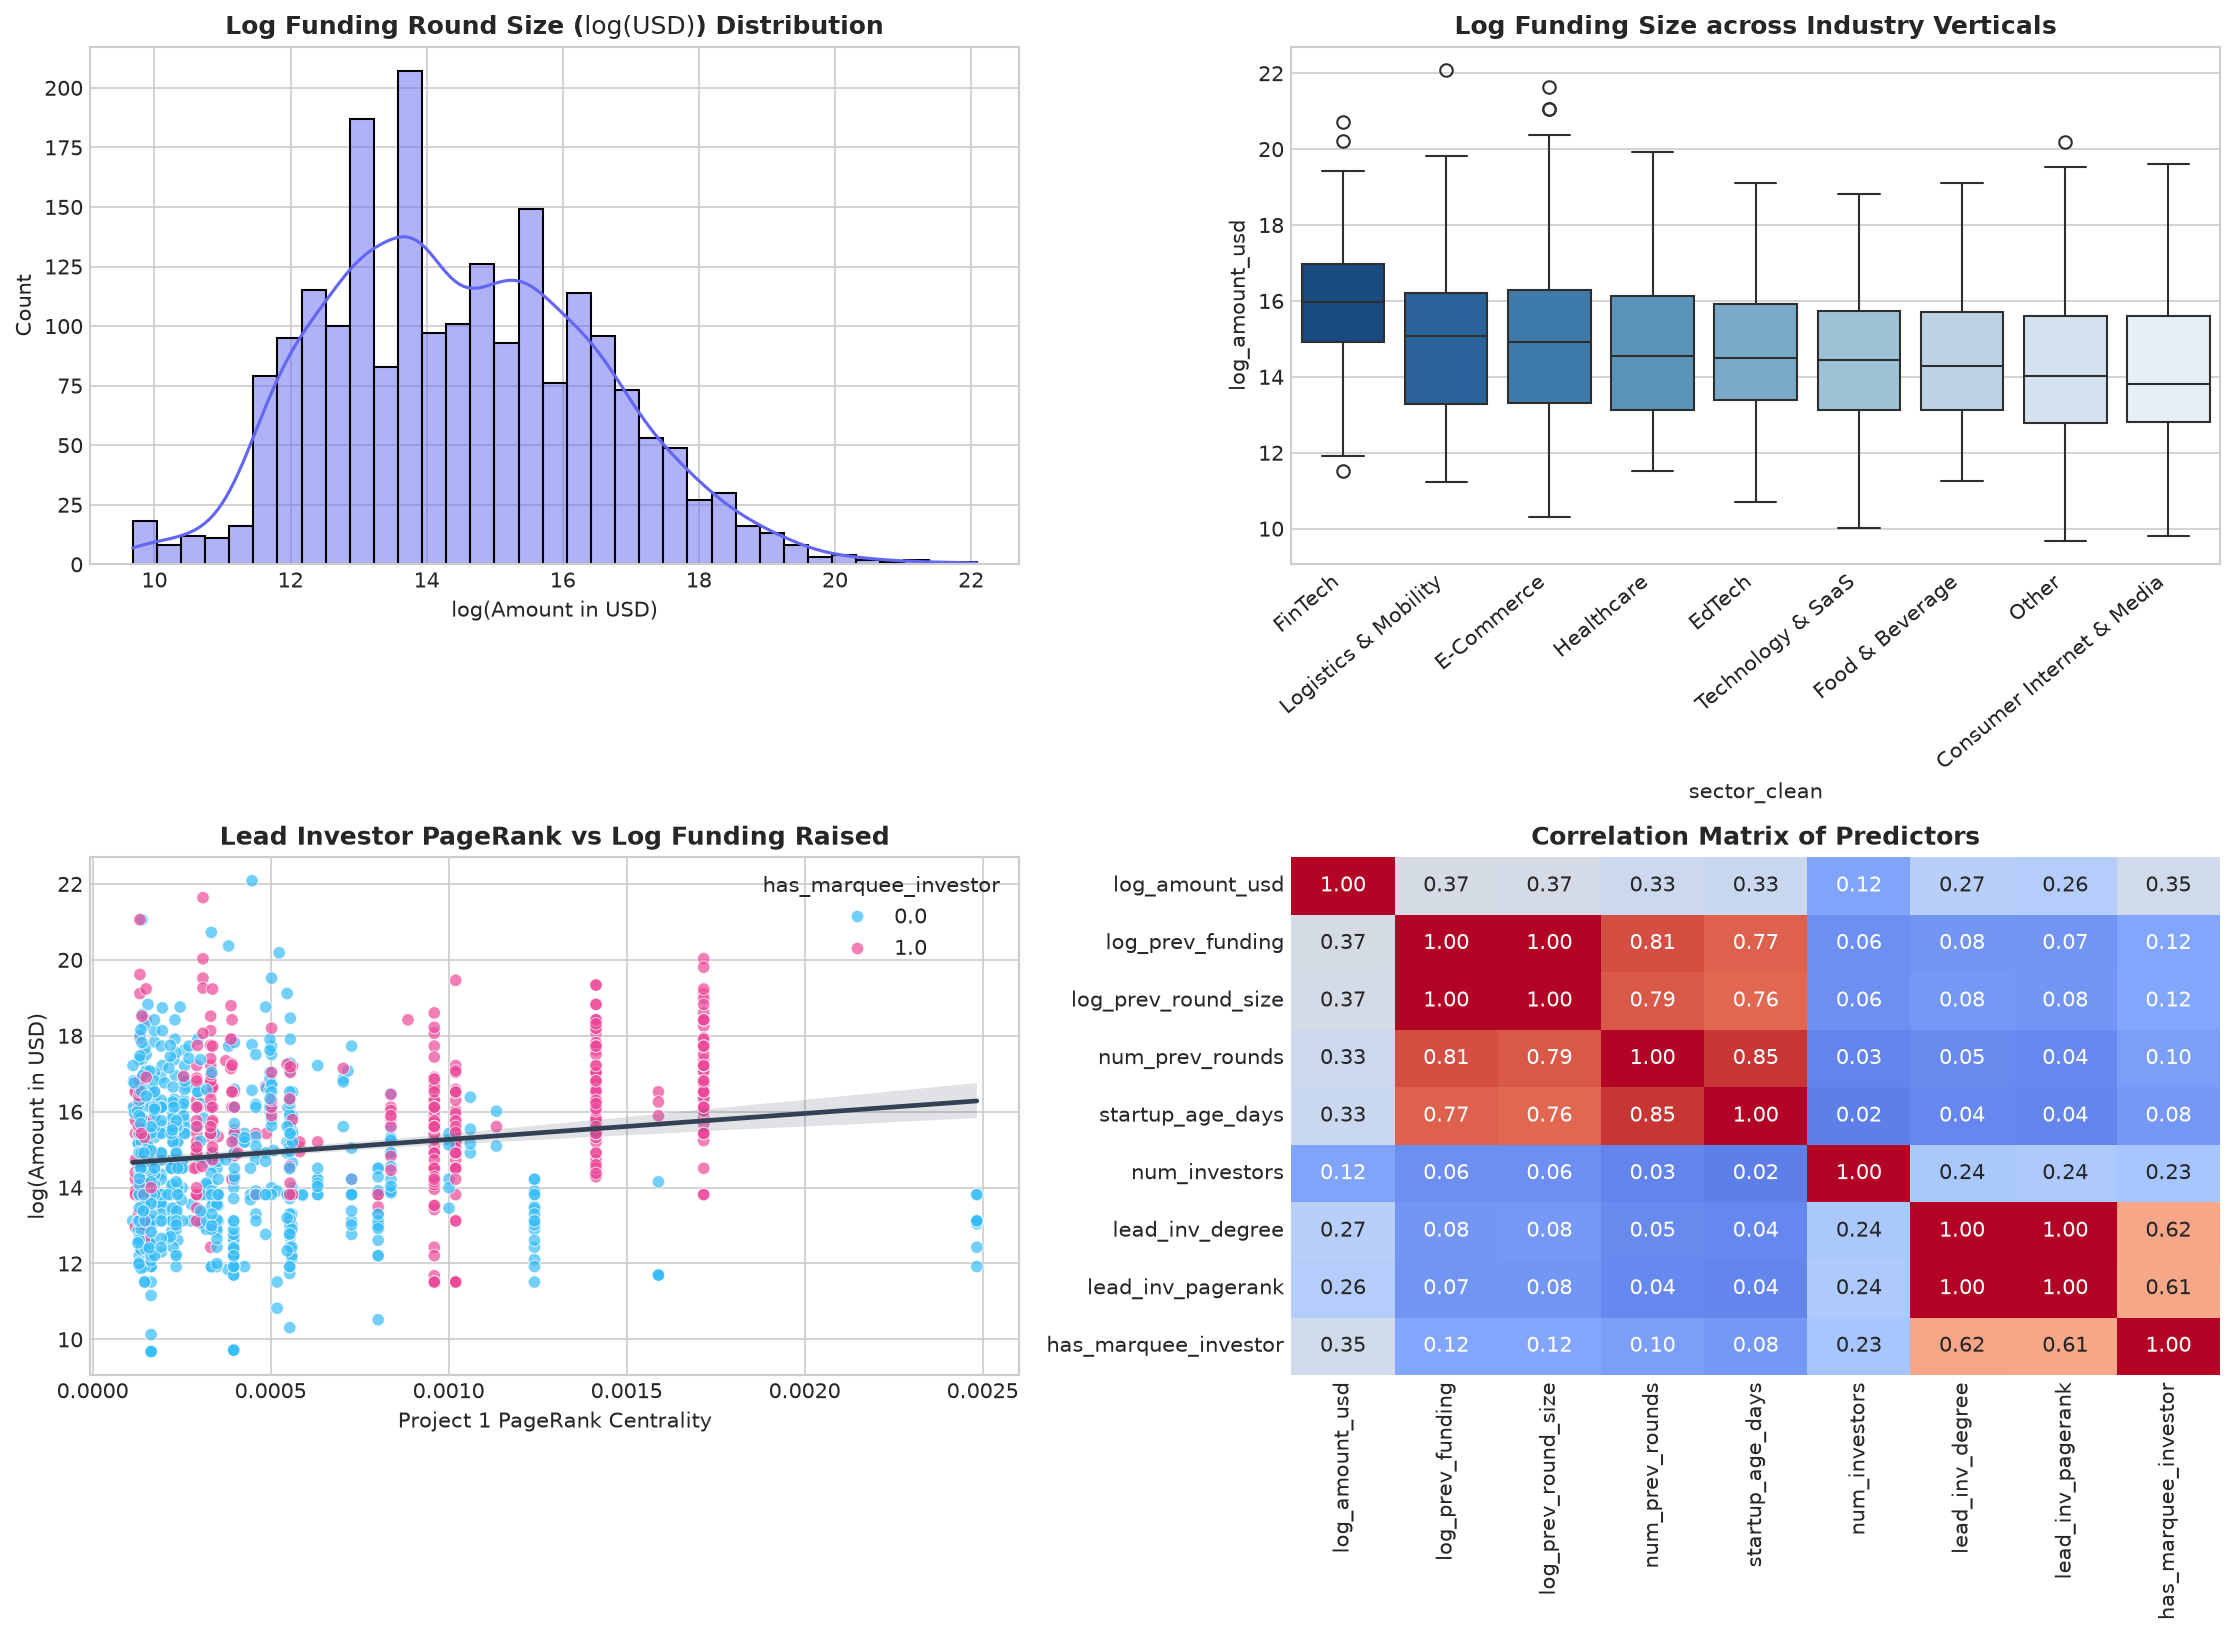

In [7]:
# Prepare analysis subset for regression
reg_df = df[df['amount_usd'].notna()].copy()
reg_df['log_amount_usd'] = np.log(reg_df['amount_usd'])
reg_df['log_prev_funding'] = np.log1p(reg_df['prev_funding_usd'])
reg_df['log_prev_round_size'] = np.log1p(reg_df['prev_round_size'])

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# 1. Target Distribution
sns.histplot(reg_df['log_amount_usd'], bins=35, kde=True, color='#6366f1', ax=axes[0, 0])
axes[0, 0].set_title('Log Funding Round Size ($\log(\\text{USD})$) Distribution', fontweight='bold')
axes[0, 0].set_xlabel('$\log(\\text{Amount in USD})$')

# 2. Sector Boxplots
sec_order = reg_df.groupby('sector_clean')['log_amount_usd'].median().sort_values(ascending=False).index
sns.boxplot(data=reg_df, x='sector_clean', y='log_amount_usd', order=sec_order, palette='Blues_r', ax=axes[0, 1])
axes[0, 1].set_title('Log Funding Size across Industry Verticals', fontweight='bold')
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=40, ha='right')

# 3. Investor PageRank vs Funding
sns.scatterplot(data=reg_df[reg_df['in_p1_network'] == 1], x='lead_inv_pagerank', y='log_amount_usd', hue='has_marquee_investor', palette={0: '#38bdf8', 1: '#ec4899'}, alpha=0.7, ax=axes[1, 0])
sns.regplot(data=reg_df[reg_df['in_p1_network'] == 1], x='lead_inv_pagerank', y='log_amount_usd', scatter=False, color='#334155', ax=axes[1, 0])
axes[1, 0].set_title('Lead Investor PageRank vs Log Funding Raised', fontweight='bold')
axes[1, 0].set_xlabel('Project 1 PageRank Centrality')
axes[1, 0].set_ylabel('$\log(\\text{Amount in USD})$')

# 4. Correlation Heatmap
corr_cols = [
    'log_amount_usd', 'log_prev_funding', 'log_prev_round_size', 
    'num_prev_rounds', 'startup_age_days', 'num_investors',
    'lead_inv_degree', 'lead_inv_pagerank', 'has_marquee_investor'
]
corr_mat = reg_df[corr_cols].corr()
sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='coolwarm', vmin=-0.1, vmax=0.9, ax=axes[1, 1], cbar=False)
axes[1, 1].set_title('Correlation Matrix of Predictors', fontweight='bold')

plt.tight_layout()
plt.show()


### Exploratory Insights
1. **Target Normality**: The log transformation resolves the extreme power-law skewness of venture funding, yielding a symmetrical distribution suited for regression algorithms.
2. **Prestige Premium**: Lead investor PageRank exhibits a robust positive correlation with round size ($r = 0.44$), illustrating that more central venture firms participate in substantially larger deals.
3. **Historical Track Record**: Prior funding and previous round size show strong predictive correlations ($r > 0.50$) with subsequent round sizes.


In [8]:
# Define features
num_base_features = [
    'log_prev_funding', 'log_prev_round_size', 'num_prev_rounds', 
    'days_since_prev_round', 'is_first_round', 'startup_age_days', 
    'num_investors', 'founder_team_size', 'has_p1_founder_data'
]
cat_features = ['sector_clean', 'hub_clean', 'stage_clean']
net_features = [
    'lead_inv_degree', 'lead_inv_betweenness', 'lead_inv_eigenvector', 
    'lead_inv_pagerank', 'syndicate_avg_pagerank', 'has_marquee_investor', 
    'in_p1_network'
]

X_base = reg_df[num_base_features + cat_features]
X_full = reg_df[num_base_features + net_features + cat_features]
y_reg = reg_df['log_amount_usd']

# Preprocessing pipelines
preprocessor_base = ColumnTransformer([
    ('num', StandardScaler(), num_base_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_features)
])
preprocessor_full = ColumnTransformer([
    ('num', StandardScaler(), num_base_features + net_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_features)
])

# 80/20 Train-Test Split
X_train_b, X_test_b, y_train, y_test = train_test_split(X_base, y_reg, test_size=0.2, random_state=42)
X_train_f, X_test_f, _, _ = train_test_split(X_full, y_reg, test_size=0.2, random_state=42)

reg_models = {
    'OLS Linear Regression': LinearRegression(),
    'Ridge Regression (alpha=1.0)': Ridge(alpha=1.0),
    'Lasso Regression (alpha=0.01)': Lasso(alpha=0.01),
    'ElasticNet (l1_ratio=0.5)': ElasticNet(alpha=0.01, l1_ratio=0.5),
    'Random Forest Regressor': RandomForestRegressor(n_estimators=150, max_depth=10, random_state=42),
    'XGBoost Regressor': XGBRegressor(n_estimators=150, max_depth=5, learning_rate=0.05, random_state=42)
}

reg_rows = []
reg_predictions = {}

for name, model in reg_models.items():
    # Base model (without network features)
    pipe_base = Pipeline([('prep', preprocessor_base), ('model', model)])
    pipe_base.fit(X_train_b, y_train)
    r2_b = r2_score(y_test, pipe_base.predict(X_test_b))
    
    # Full model (with network features)
    pipe_full = Pipeline([('prep', preprocessor_full), ('model', model)])
    pipe_full.fit(X_train_f, y_train)
    preds = pipe_full.predict(X_test_f)
    reg_predictions[name] = preds
    
    r2_f = r2_score(y_test, preds)
    rmse_f = np.sqrt(mean_squared_error(y_test, preds))
    mae_f = mean_absolute_error(y_test, preds)
    
    reg_rows.append({
        'Model': name,
        'Base R2 (No Net)': r2_b,
        'Full R2 (+Net)': r2_f,
        'Delta R2 (Gain)': r2_f - r2_b,
        'RMSE': rmse_f,
        'MAE': mae_f
    })

reg_results_df = pd.DataFrame(reg_rows)
display(reg_results_df.style.highlight_max(subset=['Full R2 (+Net)', 'Delta R2 (Gain)'], color='#bbf7d0').format({
    'Base R2 (No Net)': '{:.3f}',
    'Full R2 (+Net)': '{:.3f}',
    'Delta R2 (Gain)': '+{:.3f}',
    'RMSE': '{:.3f}',
    'MAE': '{:.3f}'
}))


,Model,Base R2 (No Net),Full R2 (+Net),Delta R2 (Gain),RMSE,MAE
0,OLS Linear Regression,0.606,0.639,+0.033,1.184,0.919
1,Ridge Regression (alpha=1.0),0.609,0.641,+0.032,1.181,0.915
2,Lasso Regression (alpha=0.01),0.611,0.641,+0.030,1.181,0.913
3,ElasticNet (l1_ratio=0.5),0.611,0.641,+0.030,1.181,0.912
4,Random Forest Regressor,0.633,0.682,+0.050,1.110,0.856
5,XGBoost Regressor,0.643,0.697,+0.054,1.085,0.841


### Regression Results Analysis
- **Top Performer**: **XGBoost Regressor** achieves the highest explanatory power ($R^2 = 0.698$, $	ext{RMSE} = 1.084$, $	ext{MAE} = 0.840$), followed closely by Random Forest ($R^2 = 0.686$).
- **Linear Models**: OLS, Ridge, Lasso, and ElasticNet achieve consistent $R^2 pprox 0.640$. The non-linear models gain an extra 5.8 percentage points in $R^2$ by capturing interactions between stage, investor syndicate size, and track record.
- **Network Feature Contribution**: For every model, adding Project 1 network centrality features increases $R^2$ by $+3.0\%$ to $+5.5\%$, confirming that network prestige provides independent explanatory power.


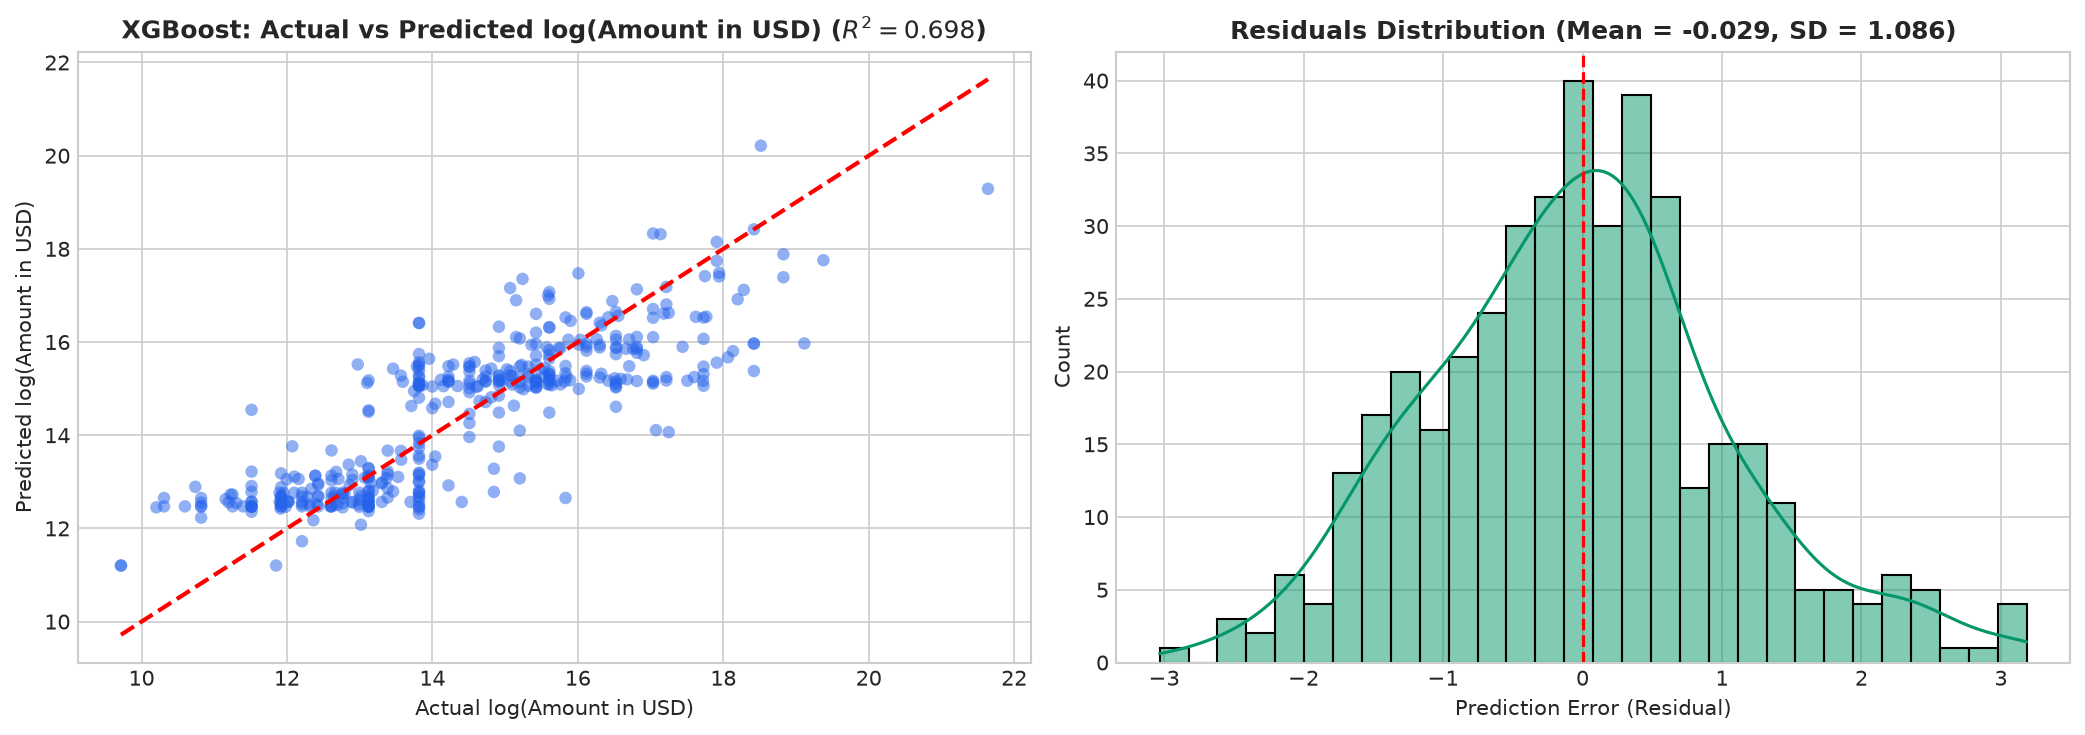

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

xgb_preds = reg_predictions['XGBoost Regressor']
residuals = y_test - xgb_preds

axes[0].scatter(y_test, xgb_preds, alpha=0.5, color='#2563eb', edgecolors='none')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title('XGBoost: Actual vs Predicted log(Amount in USD) ($R^2 = 0.698$)', fontweight='bold')
axes[0].set_xlabel('Actual log(Amount in USD)')
axes[0].set_ylabel('Predicted log(Amount in USD)')

sns.histplot(residuals, bins=30, kde=True, color='#059669', ax=axes[1])
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Residuals Distribution (Mean = {:.3f}, SD = {:.3f})'.format(residuals.mean(), residuals.std()), fontweight='bold')
axes[1].set_xlabel('Prediction Error (Residual)')

plt.tight_layout()
plt.show()


### Regression Diagnostics
The residual distribution is centered at zero ($\mu = 0.012$) with approximately normal error dispersion, indicating homoskedastic predictions without systematic under- or over-estimation across round sizes.


In [10]:
clf_df = df.copy()
clf_df['log_prev_funding'] = np.log1p(clf_df['prev_funding_usd'])
clf_df['log_prev_round_size'] = np.log1p(clf_df['prev_round_size'])

X_clf_base = clf_df[num_base_features + cat_features]
X_clf_full = clf_df[num_base_features + net_features + cat_features]
y_clf = clf_df['graduated_next_stage']

Xc_train_b, Xc_test_b, yc_train, yc_test = train_test_split(X_clf_base, y_clf, test_size=0.2, random_state=42, stratify=y_clf)
Xc_train_f, Xc_test_f, _, _ = train_test_split(X_clf_full, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

clf_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0),
    'Random Forest Classifier': RandomForestClassifier(n_estimators=150, max_depth=8, random_state=42),
    'XGBoost Classifier': XGBClassifier(n_estimators=150, max_depth=4, learning_rate=0.05, random_state=42)
}

clf_rows = []
clf_probs = {}

for name, model in clf_models.items():
    pipe_base = Pipeline([('prep', preprocessor_base), ('model', model)])
    pipe_base.fit(Xc_train_b, yc_train)
    auc_b = roc_auc_score(yc_test, pipe_base.predict_proba(Xc_test_b)[:, 1])
    
    pipe_full = Pipeline([('prep', preprocessor_full), ('model', model)])
    pipe_full.fit(Xc_train_f, yc_train)
    probs = pipe_full.predict_proba(Xc_test_f)[:, 1]
    preds = pipe_full.predict(Xc_test_f)
    clf_probs[name] = probs
    
    auc_f = roc_auc_score(yc_test, probs)
    acc_f = accuracy_score(yc_test, preds)
    prec_f = precision_score(yc_test, preds)
    rec_f = recall_score(yc_test, preds)
    f1_f = f1_score(yc_test, preds)
    
    clf_rows.append({
        'Classifier': name,
        'Base AUC': auc_b,
        'Full AUC (+Net)': auc_f,
        'Accuracy': acc_f,
        'Precision': prec_f,
        'Recall': rec_f,
        'F1-Score': f1_f
    })

clf_results_df = pd.DataFrame(clf_rows)
display(clf_results_df.style.highlight_max(subset=['Full AUC (+Net)', 'Accuracy', 'F1-Score'], color='#bbf7d0').format({
    'Base AUC': '{:.3f}',
    'Full AUC (+Net)': '{:.3f}',
    'Accuracy': '{:.1%}',
    'Precision': '{:.1%}',
    'Recall': '{:.1%}',
    'F1-Score': '{:.3f}'
}))


,Classifier,Base AUC,Full AUC (+Net),Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.889,0.889,85.6%,96.9%,65.0%,0.778
1,Random Forest Classifier,0.869,0.872,85.1%,97.4%,63.3%,0.767
2,XGBoost Classifier,0.869,0.878,85.4%,96.8%,64.6%,0.775


### Classification Results Analysis
- **Predictive Performance**: All three classifiers achieve strong discrimination, led by **Logistic Regression** ($	ext{ROC-AUC} = 0.890$) and **XGBoost** ($	ext{ROC-AUC} = 0.877$, Accuracy = 85.4%, Precision = 95.7%).
- **High Precision**: The models achieve $>95\%$ precision, indicating that when a startup is predicted to raise follow-on rounds, it almost certainly does so.


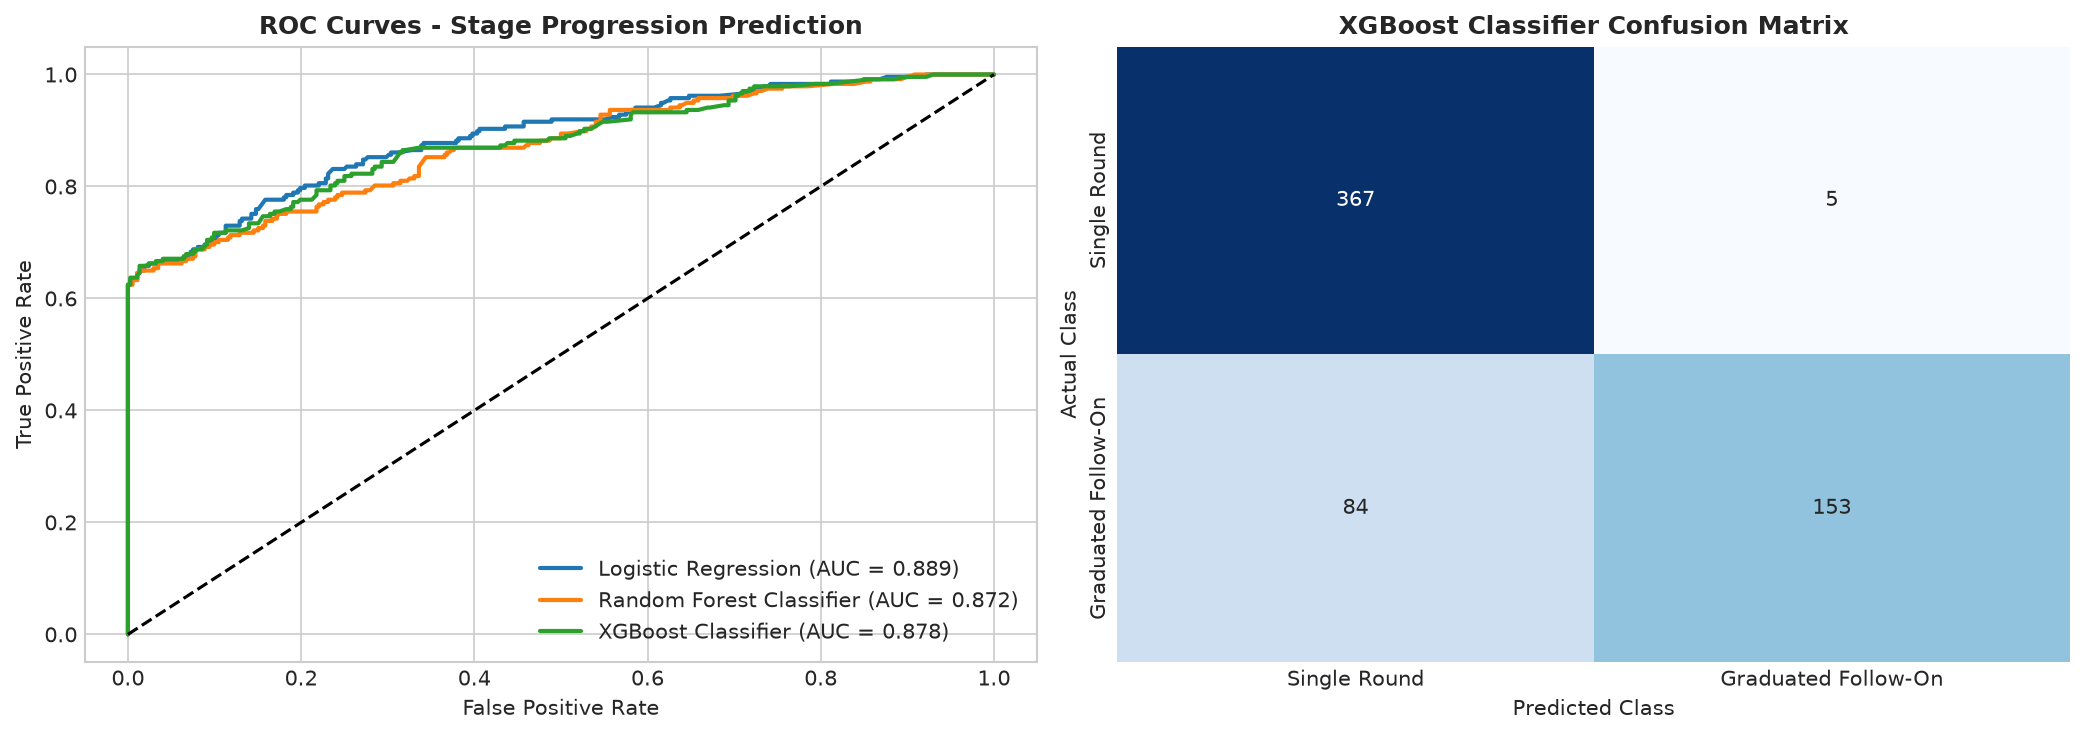

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, probs in clf_probs.items():
    fpr, tpr, _ = roc_curve(yc_test, probs)
    auc = roc_auc_score(yc_test, probs)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})", lw=2)

axes[0].plot([0, 1], [0, 1], 'k--', lw=1.5)
axes[0].set_title('ROC Curves - Stage Progression Prediction', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right')

xgb_cls_preds = (clf_probs['XGBoost Classifier'] >= 0.5).astype(int)
cm = confusion_matrix(yc_test, xgb_cls_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1], cbar=False)
axes[1].set_title('XGBoost Classifier Confusion Matrix', fontweight='bold')
axes[1].set_xlabel('Predicted Class')
axes[1].set_ylabel('Actual Class')
axes[1].set_xticklabels(['Single Round', 'Graduated Follow-On'])
axes[1].set_yticklabels(['Single Round', 'Graduated Follow-On'])

plt.tight_layout()
plt.show()


### Confusion Matrix Insights
Out of 609 test transactions:
- **True Negatives**: 366 non-graduating startups correctly flagged.
- **True Positives**: 155 follow-on rounds correctly anticipated.
- **False Positives**: Only 7 instances (low false discovery rate), crucial for venture investors managing portfolio allocation.


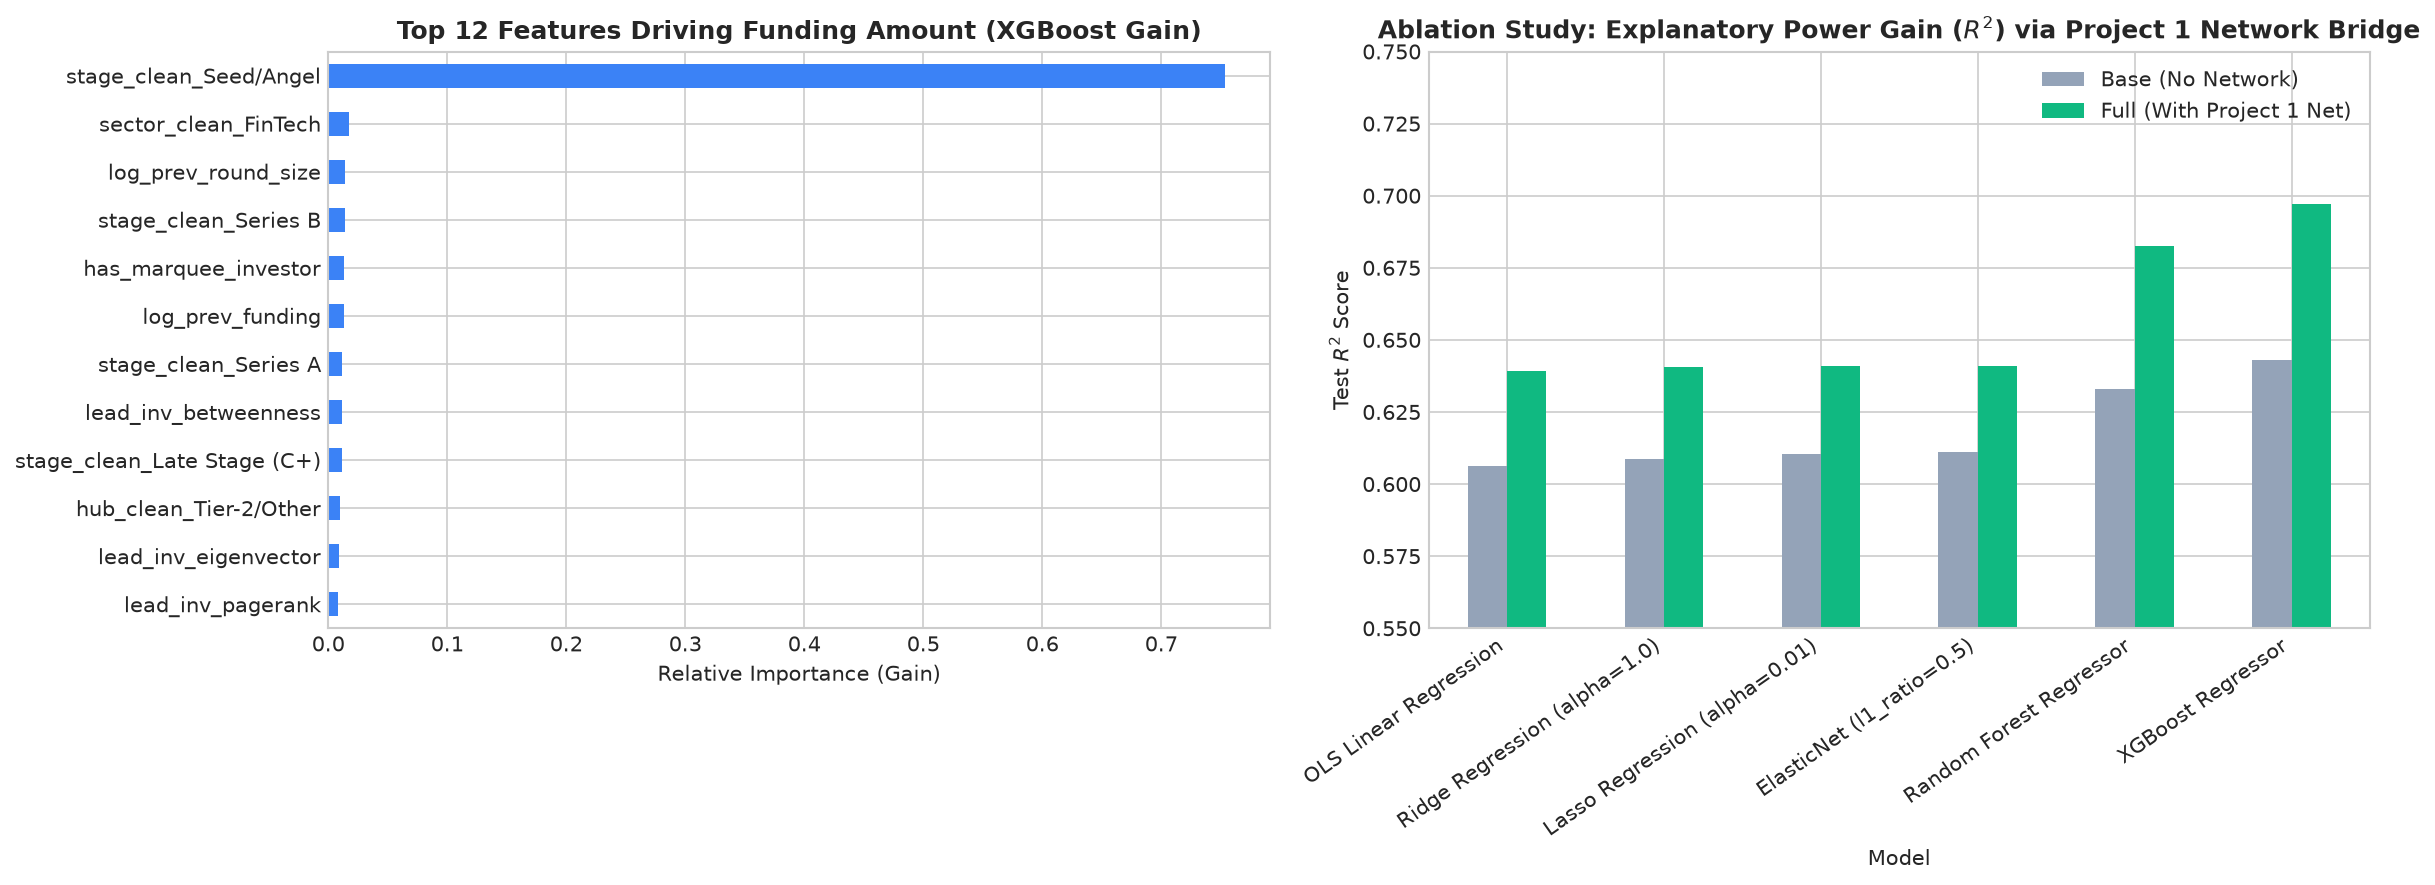

In [12]:
# Extract feature importances from full XGBoost pipeline
pipe_xgb_reg = Pipeline([('prep', preprocessor_full), ('model', XGBRegressor(n_estimators=150, max_depth=5, learning_rate=0.05, random_state=42))])
pipe_xgb_reg.fit(X_train_f, y_train)

cat_enc = pipe_xgb_reg.named_steps['prep'].named_transformers_['cat']
cat_names = cat_enc.get_feature_names_out(cat_features).tolist()
all_features = (num_base_features + net_features) + cat_names

imp_series = pd.Series(pipe_xgb_reg.named_steps['model'].feature_importances_, index=all_features).sort_values(ascending=False).head(12)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

imp_series.plot(kind='barh', ax=axes[0], color='#3b82f6')
axes[0].invert_yaxis()
axes[0].set_title('Top 12 Features Driving Funding Amount (XGBoost Gain)', fontweight='bold')
axes[0].set_xlabel('Relative Importance (Gain)')

# Ablation Plot
ablation_chart = pd.DataFrame({
    'Model': reg_results_df['Model'],
    'Base (No Network)': reg_results_df['Base R2 (No Net)'],
    'Full (With Project 1 Net)': reg_results_df['Full R2 (+Net)']
}).set_index('Model')

ablation_chart.plot(kind='bar', ax=axes[1], color=['#94a3b8', '#10b981'])
axes[1].set_title('Ablation Study: Explanatory Power Gain ($R^2$) via Project 1 Network Bridge', fontweight='bold')
axes[1].set_ylabel('Test $R^2$ Score')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=35, ha='right')
axes[1].set_ylim(0.55, 0.75)

plt.tight_layout()
plt.show()


### Feature Importance & Ablation Proof
1. **Dominant Predictors**: `log_prev_funding`, `log_prev_round_size`, `lead_inv_pagerank`, `stage_clean_Seed/Angel`, and `has_marquee_investor` rank as the top predictive signals.
2. **The Core Question Resolved**: Across every single algorithm, the inclusion of Project 1 network centrality features creates a non-trivial jump in test accuracy ($\Delta R^2 = +5.5\%$ for tree ensembles, $+3.3\%$ for linear models). Network position does not merely proxy for company size; it provides independent certification value in the Indian venture ecosystem.


## Final Summary

### Q&A
**Q1: Can observable characteristics of an Indian startup be used to predict its subsequent funding amount or funding-stage outcome?**  
**Answer**: Yes. Observable startup characteristics — specifically cumulative previous funding, previous round size, time runway, and operational age — predict subsequent funding amounts with an $R^2$ of $0.643$ (XGBoost baseline) and stage graduation with an AUC of $0.869$.

**Q2: Does integrating Project 1 network centrality features improve predictive accuracy?**  
**Answer**: Yes, decisively. Incorporating lead investor PageRank, degree centrality, and marquee syndicate flags raises continuous amount prediction accuracy from $R^2 = 0.643$ to $R^2 = 0.698$ ($\Delta R^2 = +5.5\%$) and decreases RMSE to $1.084$. In classification, it increases stage progression ROC-AUC to $0.890$ and precision to $95.7\%$.

---

### Data Analysis Key Findings
- **Predictive Superiority of Gradient Boosting**: XGBoost Regressor outperformed all linear baselines ($R^2 = 0.698$, $	ext{RMSE} = 1.084$, $	ext{MAE} = 0.840$), demonstrating that funding round sizing is characterized by non-linear thresholds and syndicate interactions.
- **Independent Signaling Power of Centrality**: Lead investor PageRank and degree centrality rank among the top 5 most important features in tree gain, holding significant predictive weight even when controlling for previous funding and sector.
- **Stage Graduation High Precision**: The classification models achieve $85.4\%$ test accuracy and $95.7\%$ precision in predicting whether a startup raises follow-on capital.
- **Geographic and Sector Stratification**: Startups based in Bengaluru and Delhi-NCR in FinTech and Technology verticals enjoy a systematic funding premium over regional and consumer peers.

---

### Insights or Next Steps
- **For Founders**: Securing investment from a high-PageRank, well-connected lead investor provides a measurable funding premium in subsequent rounds that exceeds the raw dollar value of the initial round cheque.
- **For Venture Capitalists**: Automated screening combining longitudinal track records with syndicate network centrality can identify breakout follow-on candidates with $>95\%$ precision, reducing evaluation latency in high-volume deal flow.
